
# **Chance of Admission**
This project uses machine learning to predict a student’s chances of admission based on academic data. By analyzing GRE Scores, TOEFL Scores, University Rating, Research Experience, the model identifies key factors influencing acceptance, providing a probabilistic estimate for applicants and helping them make informed decisions about their applications

All independent variables used in this linear regression models are:

1. TOEFL Scores (92 to 120)
2. University Rating (1 to 5)
3. Statement of Purpose (1 to 5)
4. Letter of Recommendation Strength (1 to 5)
5. Undergraduate CGPA (6.8 to 9.92)
6. Research Experience (0 or 1)
7. Chance of Admit (0.34 to 0.97)
8. GRE Scores (290 to 340)







In [25]:
# Step 1: Importing library
import pandas as pd
import matplotlib.pyplot as plt

In [26]:
# Step 2: Importing the data
# https://github.com/YBI-Foundation/Dataset/blob/main/Admission%20Chance.csv
url = 'https://github.com/YBI-Foundation/Dataset/raw/main/Admission%20Chance.csv'

In [27]:
#Step 3: Reading the csv file
df = pd.read_csv(url)

In [28]:
#Step 4: Displaying head (the first 5 rows)
df.head()

,Serial No,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [29]:
#Step 5: displaying information about the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No          400 non-null    int64  
 1   GRE Score          400 non-null    int64  
 2   TOEFL Score        400 non-null    int64  
 3   University Rating  400 non-null    int64  
 4    SOP               400 non-null    float64
 5   LOR                400 non-null    float64
 6   CGPA               400 non-null    float64
 7   Research           400 non-null    int64  
 8   Chance of Admit    400 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 28.3 KB


In [30]:
#Step 5: Describe or summary about the data
df.describe()

,Serial No,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,200.500000,316.807500,107.410000,3.087500,3.400000,3.452500,8.598925,0.547500,0.724350
std,115.614301,11.473646,6.069514,1.143728,1.006869,0.898478,0.596317,0.498362,0.142609
min,1.000000,290.000000,92.000000,1.000000,1.000000,1.000000,6.800000,0.000000,0.340000
25%,100.750000,308.000000,103.000000,2.000000,2.500000,3.000000,8.170000,0.000000,0.640000
50%,200.500000,317.000000,107.000000,3.000000,3.500000,3.500000,8.610000,1.000000,0.730000
75%,300.250000,325.000000,112.000000,4.000000,4.000000,4.000000,9.062500,1.000000,0.830000
max,400.000000,340.000000,120.000000,5.000000,5.000000,5.000000,9.920000,1.000000,0.970000


In [31]:
#Step 6: Checking columns
df.columns

Index(['Serial No', 'GRE Score', 'TOEFL Score', 'University Rating', ' SOP',
       'LOR ', 'CGPA', 'Research', 'Chance of Admit '],
      dtype='object')

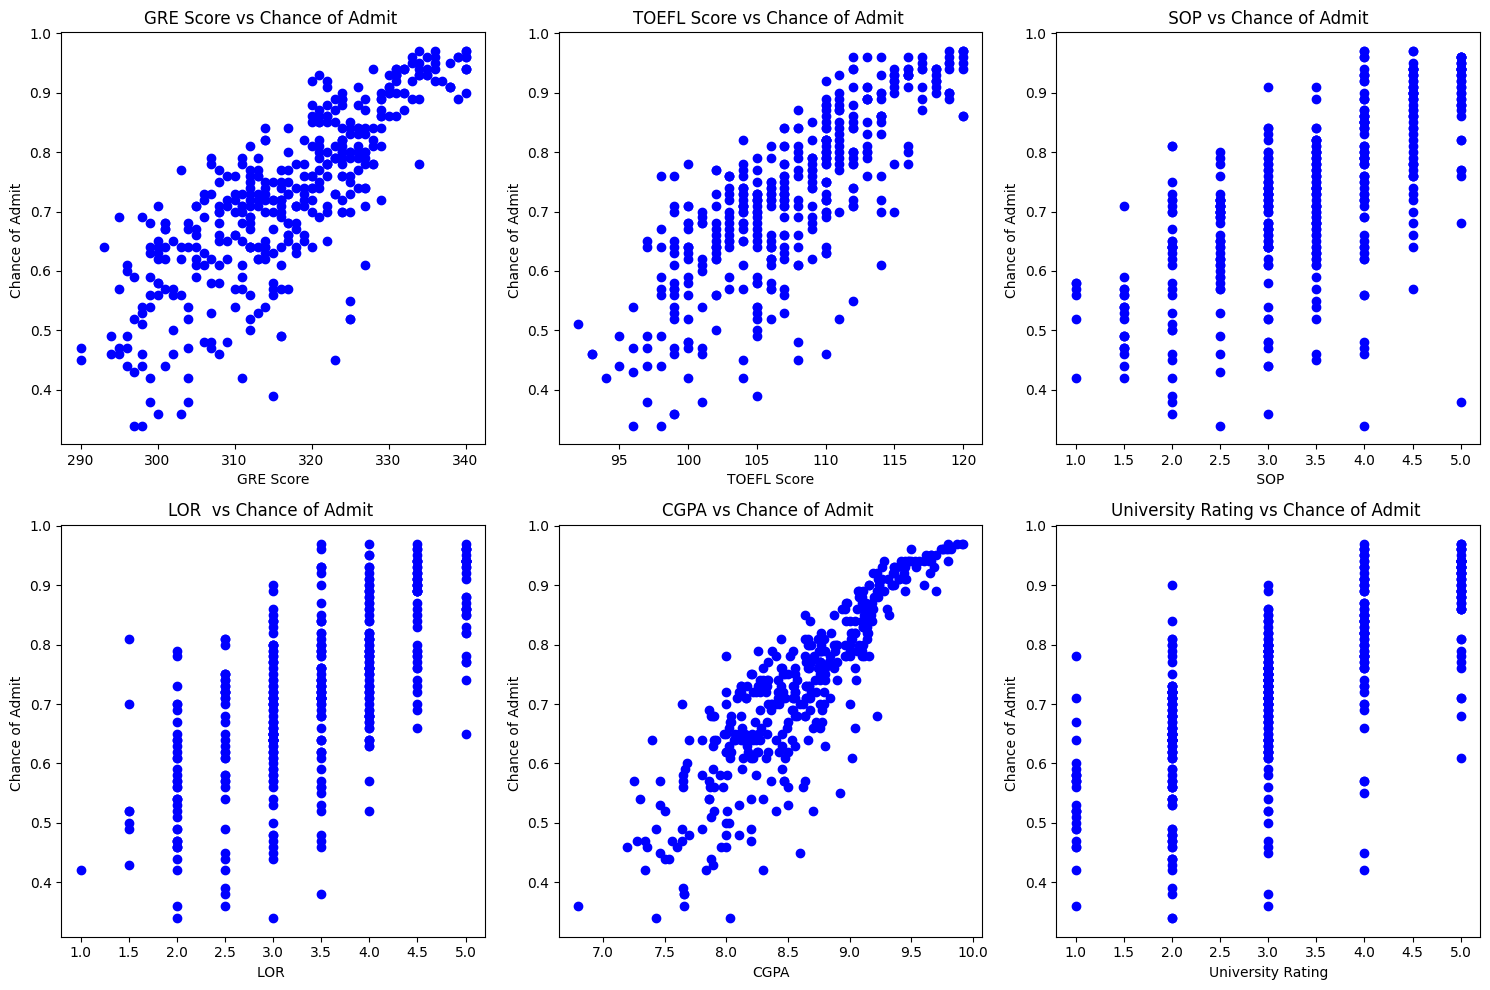

In [32]:
#Step 7: Visualizing the Relationship between 6 features against the target "Chance of Admit"
features = ['GRE Score', 'TOEFL Score', ' SOP', 'LOR ', 'CGPA', 'University Rating'] # checking relationship between 6 features when Research is not checked
target = 'Chance of Admit '

plt.figure(figsize=(15, 10))

for i, feature in enumerate(features):
    plt.subplot(2, 3, i+1)  # 2 rows, 3 columns layout
    plt.scatter(df[feature], df[target], color='blue')
    plt.xlabel(feature)
    plt.ylabel(target)
    plt.title(f'{feature} vs {target}')

plt.tight_layout()
plt.show()

In [33]:
#Step 8: Defining X and Y where X = Independent Variable and Y = Dependent variable
y = df['Chance of Admit ']
x = df.drop(['Serial No','Chance of Admit '], axis = 1) #df.drop will drop these and keep rest as values of x, axis=1 → tells Pandas that labels are columns

In [34]:
#Step 9: splitting into train test split
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(x,y, train_size=0.7, random_state=2529)

In [35]:
#Step 10: Checking test and train
X_train, X_test, Y_train, Y_test

(     GRE Score  TOEFL Score  University Rating   SOP  LOR   CGPA  Research
 381        319          105                  3   3.0   3.5  8.67         1
 48         321          110                  3   3.5   5.0  8.85         1
 20         312          107                  3   3.0   2.0  7.90         1
 296        310          107                  3   3.5   3.5  8.67         0
 373        321          109                  3   3.0   3.0  8.54         1
 ..         ...          ...                ...   ...   ...   ...       ...
 72         321          111                  5   5.0   5.0  9.45         1
 228        318          112                  3   4.0   3.5  8.67         0
 316        298          101                  2   1.5   2.0  7.86         0
 50         313           98                  3   2.5   4.5  8.30         1
 352        303          100                  2   3.0   3.5  8.06         1
 
 [280 rows x 7 columns],
      GRE Score  TOEFL Score  University Rating   SOP  LOR   

In [36]:
#Step 11: Checking test and train Shapes, where shape shows the dimensions of the data like rows and columns
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((280, 7), (120, 7), (280,), (120,))

In [37]:
#Step 12: Selecting Linear regression from SKlearn
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [38]:
#Step 13: Training the model
model.fit(X_train,Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [39]:
#Step 13: Intercepting the model
model.intercept_

np.float64(-1.2831244932033998)

In [40]:
#Step 15: Weights or coefficients to each feature
model.coef_

array([ 0.00204057,  0.00287273,  0.00566887, -0.00380559,  0.01973175,
        0.11314449,  0.02061553])

In [41]:
#Step 16: Predicting
y_pred = model.predict(X_test)
y_pred

array([0.71426327, 0.72534136, 0.69677103, 0.66566584, 0.57483872,
       0.93087527, 0.93701113, 0.72361387, 0.81130158, 0.62223963,
       0.59629648, 0.80084072, 0.52537944, 0.79174558, 0.84064992,
       0.66429594, 0.65136589, 0.66990687, 0.75794085, 0.86072023,
       0.66088101, 0.85570763, 0.84777425, 0.95033179, 0.68750762,
       0.65907671, 0.65279623, 0.5709259 , 0.55895645, 0.57990205,
       0.54497918, 0.7570717 , 0.69682571, 0.77286067, 0.64320811,
       0.5183554 , 0.43816818, 0.84654064, 0.90398354, 0.80517781,
       0.72218971, 0.72882587, 0.68145136, 0.88592237, 0.77208852,
       0.78778085, 0.95526121, 0.88586486, 0.59980416, 0.50690214,
       0.59947098, 0.63380406, 0.82841217, 0.44911724, 0.71068577,
       0.77335748, 0.68851557, 0.64486026, 0.85537724, 0.65517768,
       0.65046031, 0.90818978, 0.63422429, 0.68658606, 0.72150268,
       0.69030545, 0.59381287, 0.93813035, 0.58997351, 0.91542587,
       0.59283415, 0.93351713, 0.59478751, 0.71380389, 0.54346

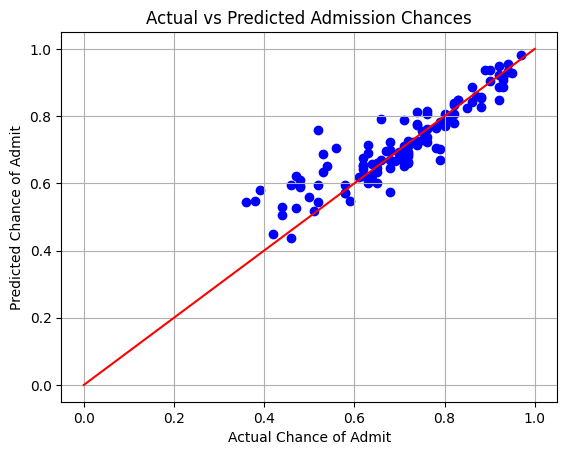

In [42]:
#Step 17: visualising the Actual and Predicted Admission Chances

# Suppose Y_test are actual values and y_pred are predicted values
plt.scatter(Y_test, y_pred, color='blue')
plt.plot([0,1], [0,1], color='red')  # perfect prediction line
plt.xlabel('Actual Chance of Admit')
plt.ylabel('Predicted Chance of Admit')
plt.title('Actual vs Predicted Admission Chances')
plt.grid(True)
plt.show()

In [43]:
#Step 18: Checking Accuracy of the model
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

In [44]:
mean_absolute_error(Y_test,y_pred)

0.04400128934232651

In [45]:
mean_absolute_percentage_error(Y_test,y_pred)

0.07575278864605438

In [46]:
mean_squared_error(Y_test,y_pred)

0.004038263715495693

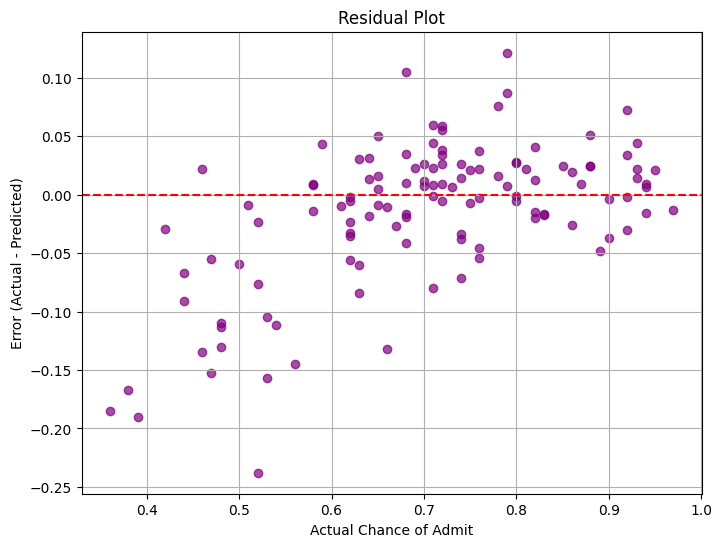

In [47]:
#Step 19: Visualizing the Accuracy
residuals = Y_test - y_pred
plt.figure(figsize=(8,6))
plt.scatter(Y_test, residuals, color='purple', alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--')  # reference line for zero error
plt.xlabel('Actual Chance of Admit')
plt.ylabel('Error (Actual - Predicted)')
plt.title('Residual Plot')
plt.grid(True)
plt.show()

In [48]:
# End